Import the Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Problem Statement:The goal is to predict students final exam scores using academic and behavioral data

Load the Student mental health Dataset

In [ ]:
df = pd.read_csv("/content/student_mental_health.csv")


In [ ]:
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,NaN,Low,Low,Yes,7.4,50.3,Medium,Yes,1,54.3
1,19.7,63.6,Medium,High,Yes,6.7,83.1,Low,Yes,2,59.4
2,24.4,98.4,Medium,Medium,Yes,NaN,63.5,Medium,Yes,0,63.8
3,29.6,NaN,Medium,High,Yes,6.3,57.5,Medium,Yes,2,61.0
4,19.1,91.5,High,Medium,Yes,6.2,66.0,Medium,Yes,2,60.7
...,...,...,...,...,...,...,...,...,...,...,...
6932,14.9,91.2,Medium,Medium,Yes,5.9,91.1,Low,Yes,3,62.5
6933,25.7,91.7,High,High,Yes,7.1,86.0,High,Yes,3,80.7
6934,9.4,76.0,Low,Medium,Yes,5.8,50.1,Medium,Yes,1,51.6
6935,21.7,99.8,Medium,High,Yes,6.7,53.0,Low,Yes,5,64.5


EDA :Basic Data Check

In [ ]:
#Check size of the Dataset
df.shape

(6937, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6937 entries, 0 to 6936
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6600 non-null   float64
 1   Attendance                  6608 non-null   float64
 2   Parental_Involvement        6937 non-null   object 
 3   Access_to_Resources         6937 non-null   object 
 4   Extracurricular_Activities  6937 non-null   object 
 5   Sleep_Hours                 6593 non-null   float64
 6   Previous_Scores             6937 non-null   float64
 7   Motivation_Level            6937 non-null   object 
 8   Internet_Access             6937 non-null   object 
 9   Tutoring_Sessions           6937 non-null   int64  
 10  Final_Exam_Score            6937 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 596.3+ KB


In [ ]:
#Check the Statistical information

df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Final_Exam_Score
count,6600.000000,6608.000000,6593.000000,6937.000000,6937.000000,6937.000000
mean,29.357000,99.445400,7.184499,74.653726,1.486522,60.383465
std,60.748485,132.993718,1.286684,14.452102,1.215943,8.758301
min,1.100000,60.000000,4.000000,50.000000,0.000000,29.700000
25%,16.600000,70.200000,6.300000,62.000000,1.000000,54.200000
50%,20.600000,80.200000,7.200000,74.600000,1.000000,60.400000
75%,24.700000,90.700000,8.100000,87.300000,2.000000,66.600000
max,440.000000,1000.000000,10.000000,100.000000,8.000000,95.200000


check null values

In [ ]:
df.isnull().sum()

,0
Hours_Studied,337
Attendance,329
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,344
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


fill the null values using mean


In [ ]:
for col in ['Hours_Studied','Attendance','Sleep_Hours']:
  df[col].fillna(df[col].mean(),inplace=True)

/tmp/ipykernel_13842/2030134763.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(),inplace=True)


handle the duplicates values

In [ ]:
df.duplicated().sum()

np.int64(330)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(6607, 11)

Split the numerical and categorical columns

In [ ]:
numerical_col = df.select_dtypes(exclude = ['object']).columns

In [ ]:
categorical_col = df.select_dtypes(include = ['object']).columns

In [ ]:
numerical_col

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Final_Exam_Score'],
      dtype='object')

In [ ]:
categorical_col

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access'],
      dtype='object')

Check the value of count

In [ ]:
for i in categorical_col:
  print(df[i].value_counts())
  print('*' * 50)

Parental_Involvement
Medium    3365
High      1968
Low       1274
Name: count, dtype: int64
**************************************************
Access_to_Resources
Medium    3349
High      1979
Low       1279
Name: count, dtype: int64
**************************************************
Extracurricular_Activities
Yes    3988
No     2619
Name: count, dtype: int64
**************************************************
Motivation_Level
Medium    3386
Low       1885
High      1336
Name: count, dtype: int64
**************************************************
Internet_Access
Yes    6093
No      514
Name: count, dtype: int64
**************************************************


In [ ]:
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,99.4454,1,1,1,7.400000,50.3,2,1,1,54.3
1,19.7,63.6000,2,3,1,6.700000,83.1,1,1,2,59.4
2,24.4,98.4000,2,2,1,7.184499,63.5,2,1,0,63.8
3,29.6,99.4454,2,3,1,6.300000,57.5,2,1,2,61.0
4,19.1,91.5000,3,2,1,6.200000,66.0,2,1,2,60.7
...,...,...,...,...,...,...,...,...,...,...,...
6601,20.9,83.2000,3,3,1,5.900000,55.3,2,1,1,47.1
6602,26.0,69.5000,3,2,0,7.000000,80.1,2,1,1,58.8
6603,23.0,99.4454,3,1,0,6.400000,93.2,1,0,2,67.0
6604,20.1,90.3000,3,1,1,7.700000,79.4,2,1,0,58.5


Univariant and Bivariant Analysis

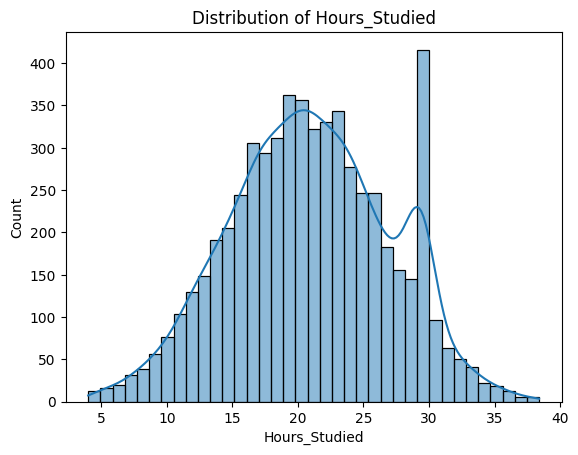

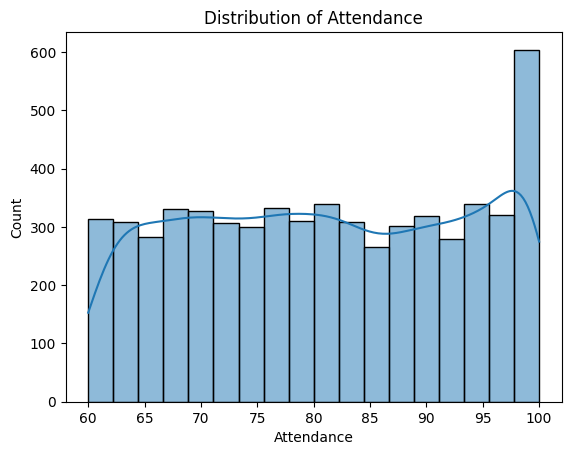

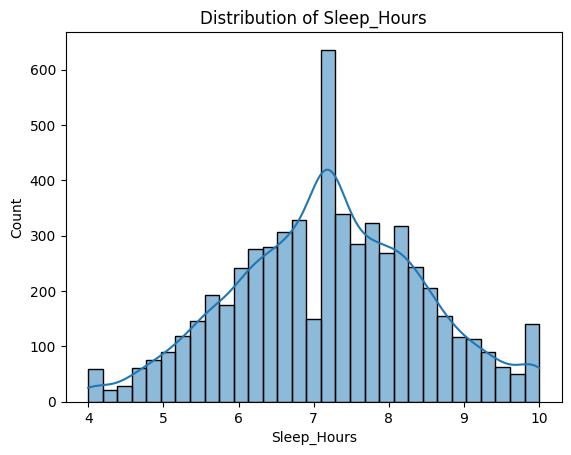

In [ ]:
for col in ["Hours_Studied","Attendance","Sleep_Hours"	]:
  sns.histplot(df[col],kde=True)
  plt.title(f"Distribution of {col}")
  plt.show()

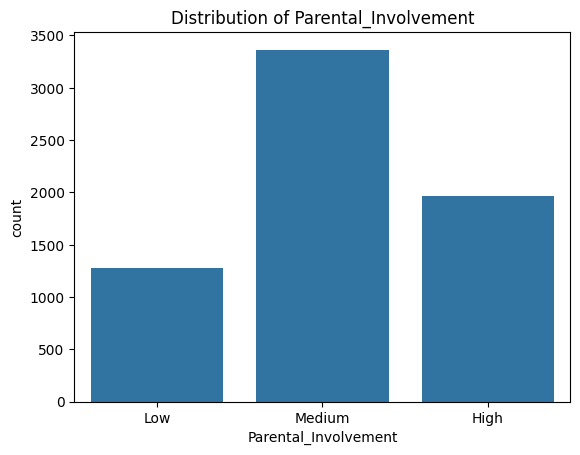

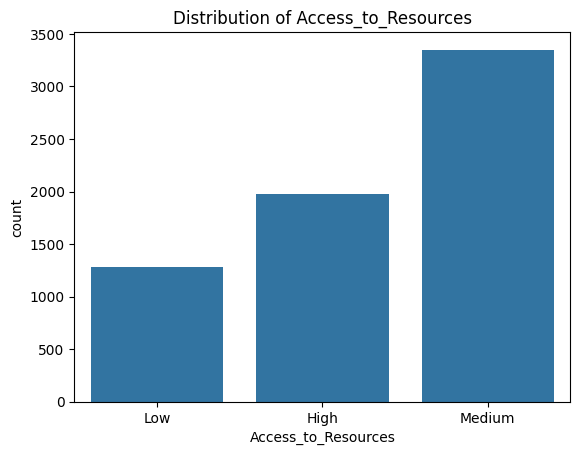

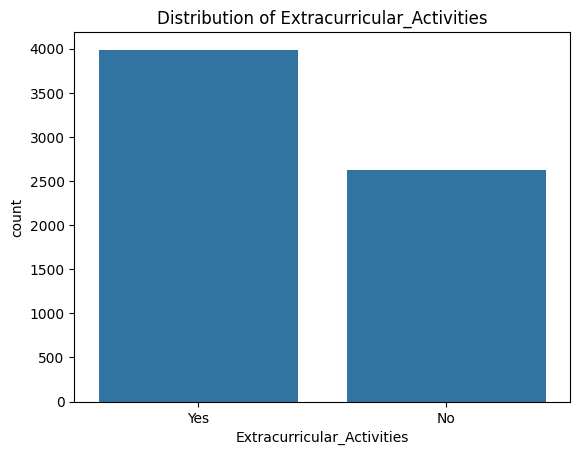

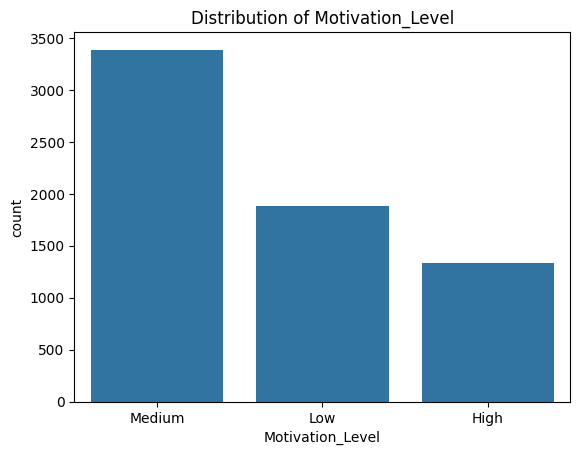

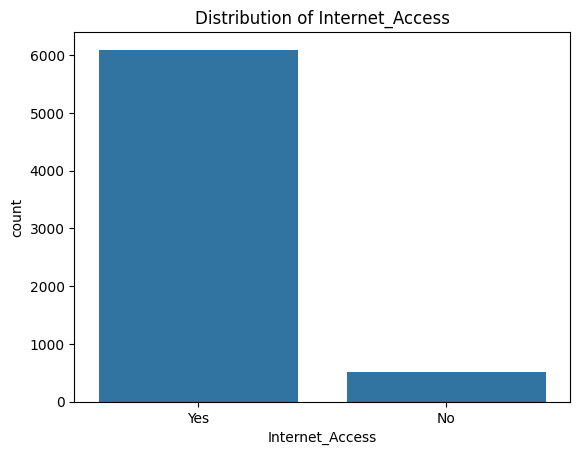

In [ ]:
for col in categorical_col:
  sns.countplot(x=df[col])
  plt.title(f"Distribution of {col}")
  plt.show()

* The scatter plot shows a positive relationship, meaning more
study hours generally lead to higher exam scores.
* There is some variation in points, indicating other factors also affect the final scores.

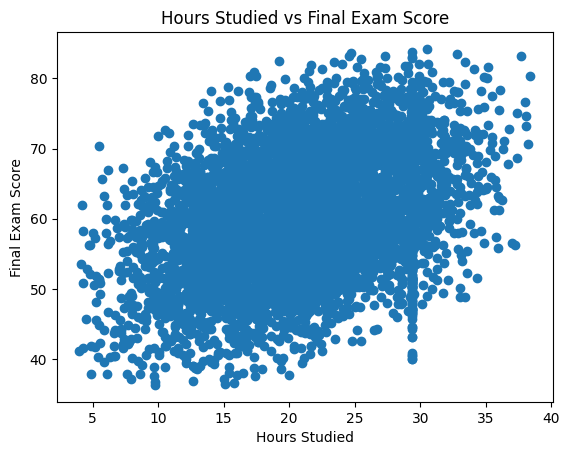

In [ ]:
# Scatter plot: Hours Studied vs Final Exam Score
plt.scatter(df["Hours_Studied"], df["Final_Exam_Score"])
plt.xlabel("Hours Studied")
plt.ylabel("Final Exam Score")
plt.title("Hours Studied vs Final Exam Score")

plt.show()

In [ ]:
df[numerical_col].corr()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Final_Exam_Score
Hours_Studied,1.000000,-0.004079,0.005352,0.023611,-0.015880,0.068145
Attendance,-0.004079,1.000000,-0.024082,0.004054,-0.006415,0.017594
Sleep_Hours,0.005352,-0.024082,1.000000,0.014406,0.000162,-0.010527
Previous_Scores,0.023611,0.004054,0.014406,1.000000,0.003964,0.653388
Tutoring_Sessions,-0.015880,-0.006415,0.000162,0.003964,1.000000,0.207310
Final_Exam_Score,0.068145,0.017594,-0.010527,0.653388,0.207310,1.000000


* A heatmap is often used to show correlation between variables.
* Helps identify strong and weak correlations quickly.





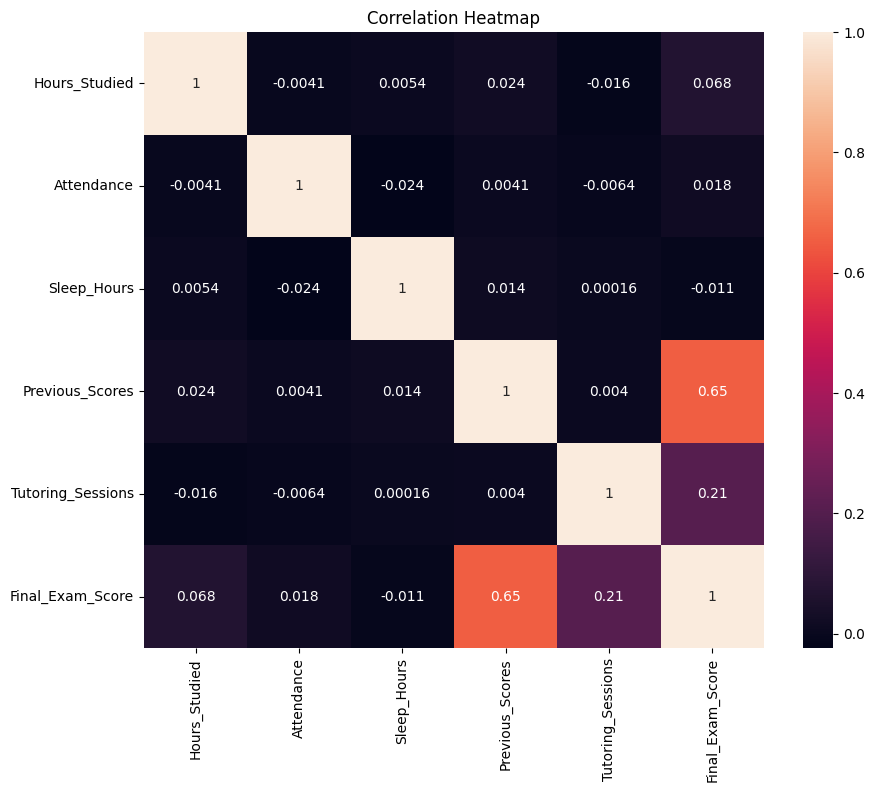

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_col].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Outlier Detection -Outlier detection is used to identify values that are very different from the rest of the data.

In [ ]:
for col in numerical_col:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  Lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  df = df[(df[col] >= Lower_bound) & (df[col] <= upper_bound)]



In [ ]:
df.shape

(5884, 11)

 Encoding

In [ ]:
mapping = {
    'Parental_Involvement': {'Low': 1, 'Medium': 2, 'High': 3},
    'Access_to_Resources': {'Low': 1, 'Medium': 2, 'High': 3},
    'Motivation_Level': {'Low': 1, 'Medium': 2, 'High': 3},
    'Extracurricular_Activities': {'No': 0, 'Yes': 1},
    'Internet_Access': {'No': 0, 'Yes': 1}
}

# Apply mapping to all columns at once
df.replace(mapping, inplace=True)

/tmp/ipykernel_13842/1100761039.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(mapping, inplace=True)


In [ ]:
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,99.4454,1,1,1,7.400000,50.3,2,1,1,54.3
1,19.7,63.6000,2,3,1,6.700000,83.1,1,1,2,59.4
2,24.4,98.4000,2,2,1,7.184499,63.5,2,1,0,63.8
3,29.6,99.4454,2,3,1,6.300000,57.5,2,1,2,61.0
4,19.1,91.5000,3,2,1,6.200000,66.0,2,1,2,60.7
...,...,...,...,...,...,...,...,...,...,...,...
6601,20.9,83.2000,3,3,1,5.900000,55.3,2,1,1,47.1
6602,26.0,69.5000,3,2,0,7.000000,80.1,2,1,1,58.8
6603,23.0,99.4454,3,1,0,6.400000,93.2,1,0,2,67.0
6604,20.1,90.3000,3,1,1,7.700000,79.4,2,1,0,58.5


Model building

In [ ]:
#Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



*   X-independent variables(feature variable)
*   y-dependent variables(target variable)



In [ ]:
X= df.drop('Final_Exam_Score',axis=1)
y= df['Final_Exam_Score']

Divide the dataset into training and testing sets

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y ,train_size=0.8)

Standard Scaling:
Bring the all feature in same scale

In [ ]:
scaler = StandardScaler()

In [ ]:
X_scaled = scaler.fit_transform(X)  #fits the scaler to the data and scales all feature values.

In [ ]:
X_scaled

array([[ 0.41814485,  1.53582745, -1.59399513, ...,  0.12223817,
         0.29121858, -0.29958405],
       [-0.20813207, -1.44313573, -0.14950609, ..., -1.32786136,
         0.29121858,  0.73186859],
       [ 0.5664736 ,  1.44894861, -0.14950609, ...,  0.12223817,
         0.29121858, -1.3310367 ],
       ...,
       [ 0.33573999,  1.53582745,  1.29498295, ..., -1.32786136,
        -3.43384687,  0.73186859],
       [-0.14220818,  0.77579105,  1.29498295, ...,  0.12223817,
         0.29121858, -1.3310367 ],
       [-1.75734339,  0.4184358 ,  1.29498295, ...,  0.12223817,
         0.29121858, -0.29958405]])

In [ ]:
lr = LinearRegression()  #creates a Linear Regression model object.
lr.fit(X_train, y_train)  #trains the model using the training data


LinearRegression()

In [ ]:
#Extract model parameters

lr.intercept_

np.float64(-6.858831636270111)

In [ ]:
#m= slope
lr.coef_

array([ 0.53182537,  0.17606835, -0.03428807,  1.973484  ,  0.29581733,
       -0.06493465,  0.39580722,  3.02755438,  0.43433125,  1.59237168])

In [ ]:
## equation of line is y = mx + c

In [ ]:
#make predictions on the test data.
y_pred = lr.predict(X_test)

In [ ]:
y_pred

array([50.64777706, 52.0391033 , 63.62615774, ..., 61.39925977,
       45.17337336, 62.48819071])

* MSE - Penalizes large errors more
* MAE - Give Average error (easy to understand)
* R² Score - Measure the model performance (closer to 1 = better model)






In [ ]:
mse_lr = mean_squared_error(y_test, y_pred)
mae_lr = mean_absolute_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)

In [ ]:
print("MSE:", mse_lr)
print("MAE:", mae_lr)
print("R2 Score:", r2_lr)

MSE: 17.890580674587433
MAE: 3.363199111516244
R2 Score: 0.7532058617802581


Sample test data

In [ ]:
test_data = pd.DataFrame([{
    'Hours_Studied': 20,
    'Attendance': 85,
    'Parental_Involvement': 'Medium',
    'Access_to_Resources': 'High',
    'Extracurricular_Activities': 'Yes',
    'Sleep_Hours': 7,
    'Previous_Scores': 65,
    'Motivation_Level': 'High',
    'Internet_Access': 'Yes',
    'Tutoring_Sessions': 2
}])

In [ ]:
from sklearn.preprocessing import LabelEncoder

cols = ['Parental_Involvement','Access_to_Resources',
        'Extracurricular_Activities','Motivation_Level','Internet_Access']

for col in cols:
    test_data[col] = LabelEncoder().fit_transform(test_data[col])

In [ ]:
test_data

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions
0,20,85,0,0,0,7,65,0,0,2


The output shows the predicted final exam score based on the input data.

In [ ]:
prediction = lr.predict(test_data)
print("Predicted Final Exam Score:", prediction)

Predicted Final Exam Score: [47.20115571]


* The graph shows actual and predicted Total_Sales values together.
* Most predicted values follow the same pattern as actual values.
* Some deviations can be seen where predictions are slightly higher or lower.
* The scatter plot shows an upward trend, indicating the model captures the overall pattern in the data





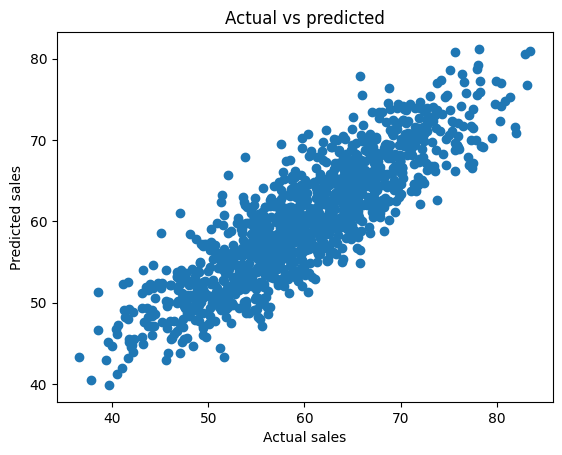

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual sales")
plt.ylabel("Predicted sales")
plt.title("Actual vs predicted")
plt.show()